# Baseline Classification Models

**Objective:** Train and evaluate multiple classification models to predict job posting experience level using the feature-engineered dataset.

**Models to compare:**
- Logistic Regression (baseline)
- XGBoost
- LightGBM
- CatBoost

**Target variable:** `experience_level_ord` (ordinal-encoded experience level)

All training and evaluation logic is implemented in `src/` and called from this notebook.

## 1. Setup and Data Loading

In [115]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Make src/ importable
sys.path.append("..\src")

print("Setup complete.")

Setup complete.


In [116]:
TRAIN_PATH = "../data/processed/feature_matrix_train.csv"
TEST_PATH = "../data/processed/feature_matrix_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (98589, 44)
Test shape:  (24709, 44)


## 2. Target and Feature Split

### 2.1 Define target and feature columns

The target is `experience_level_ord`, which is the ordinal encoding of experience level. Since this column *is* the target, it must be excluded from the feature set.

Rows where the target is missing are dropped since they cannot be used for supervised training.

In [117]:
TARGET = "experience_level_ord"

# Drop rows where target is missing
train_before = len(df_train)
test_before = len(df_test)

df_train = df_train.dropna(subset=[TARGET]).reset_index(drop=True)
df_test = df_test.dropna(subset=[TARGET]).reset_index(drop=True)

FEATURES = [col for col in df_train.columns if col != TARGET]

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)

X_test = df_test[FEATURES]
y_test = df_test[TARGET].astype(int)


print(f"Train: {train_before} -> {len(df_train)} ({train_before - len(df_train)} dropped due to missing target)")
print(f"Test:  {test_before} -> {len(df_test)} ({test_before - len(df_test)} dropped due to missing target)")

Train: 98589 -> 79440 (19149 dropped due to missing target)
Test:  24709 -> 19948 (4761 dropped due to missing target)


### 2.2 Class distribution

Check if the target classes are balanced or if we need to account for imbalance during training.

In [118]:
class_dist = y_train.value_counts().sort_index()
class_pct = y_train.value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({
    "count": class_dist,
    "percentage": class_pct.round(2)
})
dist_df.index.name = "experience_level"
print(dist_df)
print(f"\nNumber of classes: {y_train.nunique()}")

                  count  percentage
experience_level                   
0                  1594        2.01
1                 29457       37.08
2                  8504       10.70
3                 34824       43.84
4                  3733        4.70
5                  1328        1.67

Number of classes: 6


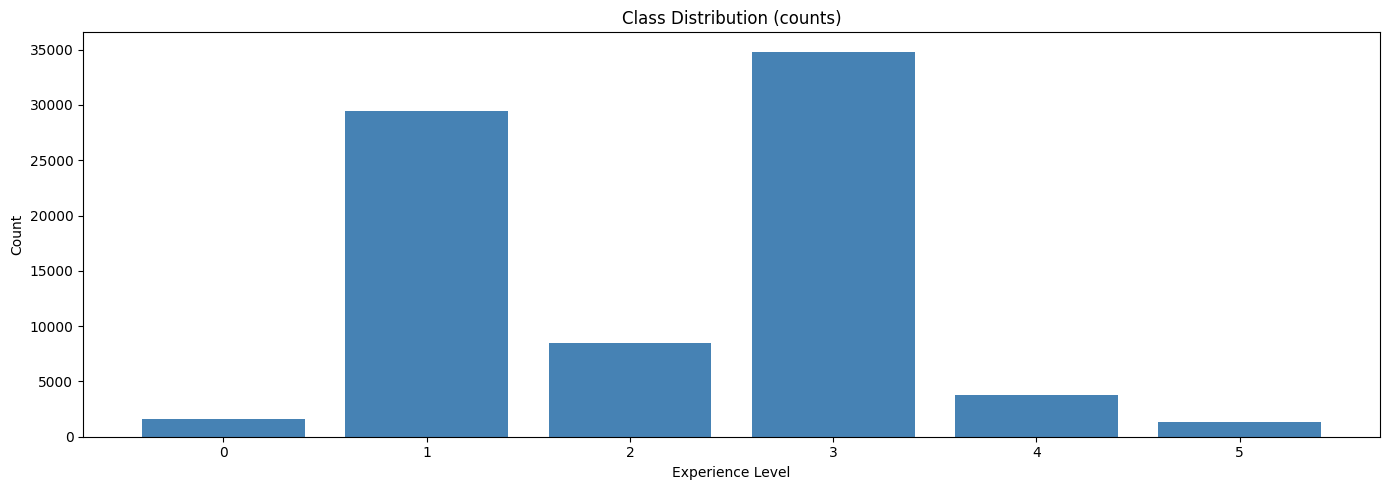

In [119]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Absolute counts
axes.bar(class_dist.index.astype(str), class_dist.values, color="steelblue")
axes.set_title("Class Distribution (counts)")
axes.set_xlabel("Experience Level")
axes.set_ylabel("Count")

plt.tight_layout()
plt.show()

### 2.3 Missing values in features

Quick overview of which features have missing values and how much. This matters because Logistic Regression cannot handle NaNs natively, while tree-based models (XGBoost, LightGBM, CatBoost) can.

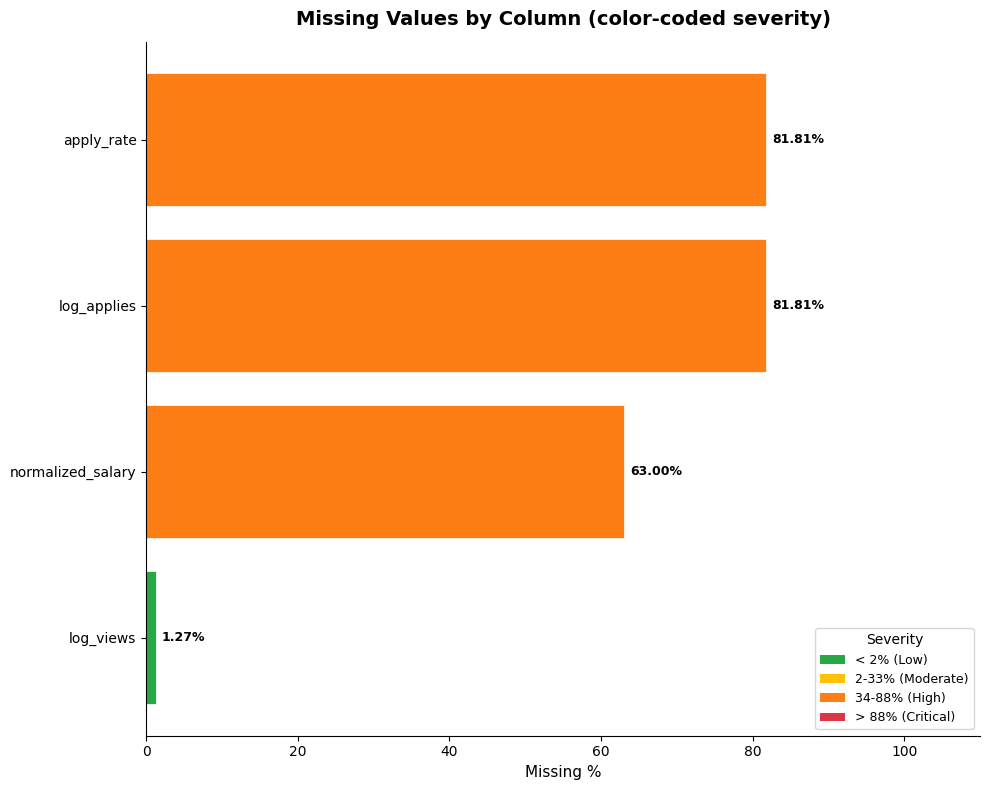

In [120]:
missing_pct = (df_train.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]  # only columns with missing values

def severity_color(pct):
    if pct < 2:
        return '#28a745'   # green
    elif pct < 33:
        return '#ffc107'   # yellow
    elif pct < 88:
        return '#fd7e14'   # orange
    else:
        return '#dc3545'   # red

colors = [severity_color(p) for p in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

legend_items = [
    Patch(facecolor='#28a745', label='< 2% (Low)'),
    Patch(facecolor='#ffc107', label='2-33% (Moderate)'),
    Patch(facecolor='#fd7e14', label='34-88% (High)'),
    Patch(facecolor='#dc3545', label='> 88% (Critical)')
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, title='Severity', title_fontsize=10)

ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Values by Column (color-coded severity)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Evaluation Utilities

Evaluation logic lives in `src/utils/evaluation.py` and is imported here. All models will be evaluated through the same functions for consistency.

**Key metric choices given class imbalance:**

| Class | Label | Share |
|-------|-------|-------|
| 0 | Internship | 2.01% |
| 1 | Entry level | 37.08% |
| 2 | Associate | 10.70% |
| 3 | Mid-Senior level | 43.84% |
| 4 | Director | 4.70% |
| 5 | Executive | 1.67% |

Classes 0, 4, and 5 together make up only ~8% of the data. A model predicting only class 1 and 3 would already reach ~81% accuracy, so accuracy alone is misleading. We track:

- **F1 macro** - primary metric, treats all 6 classes equally regardless of size
- **F1 weighted** - accounts for class frequency, gives a "realistic" performance view
- **Per-class precision/recall** - to see exactly where the model struggles (expect low recall on minority classes)
- **Normalized confusion matrix** - row-normalized so that minority classes are visible

In [121]:
from utils.evaluation import (
    evaluate_model,
    compare_models,
    plot_model_comparison,
    EXPERIENCE_LABELS,
)

print("Available experience level classes:")
for k, v in EXPERIENCE_LABELS.items():
    print(f"  {k} -> {v}")

Available experience level classes:
  0 -> Internship
  1 -> Entry level
  2 -> Associate
  3 -> Mid-Senior level
  4 -> Director
  5 -> Executive


### Evaluation workflow

Every model in the following sections will be evaluated with the same call:

```python
results["Model Name"] = evaluate_model(y_test, y_pred, model_name="Model Name")
```

This prints the classification report, shows the normalized confusion matrix, and stores the metrics dict for the final comparison. We initialize the results container here.

In [122]:
# Container to collect metrics from all models for final comparison
results = {}

## 4. Logistic Regression (Baseline)

Logistic Regression serves as the simplest baseline. It gives us a floor to beat with tree-based models.

**Why it needs extra preprocessing compared to tree models:**
- Cannot handle NaN natively, so median imputation is applied (~81% missing in apply-related features, ~63% in salary)
- Requires feature scaling since L2 regularization penalizes coefficients, and unscaled features with larger magnitudes would dominate

Both steps are wrapped inside a sklearn Pipeline so transforms stay consistent between train and test.

`class_weight='balanced'` is used to counteract the heavy class imbalance by weighting samples inversely proportional to class frequency.

In [123]:
from models.train_logreg import build_logreg_pipeline, get_feature_importance

### 4.1 Train

In [124]:
lr_pipeline = build_logreg_pipeline(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

### 4.2 Evaluate

  Logistic Regression

Accuracy:        0.3965
MAE:             1.0573
F1 (macro):      0.2962
F1 (weighted):   0.4132

                  precision    recall  f1-score   support

      Internship       0.12      0.53      0.20       376
     Entry level       0.58      0.59      0.58      7418
       Associate       0.30      0.43      0.35      2154
Mid-Senior level       0.66      0.22      0.33      8735
        Director       0.12      0.38      0.19       913
       Executive       0.07      0.41      0.12       352

        accuracy                           0.40     19948
       macro avg       0.31      0.43      0.30     19948
    weighted avg       0.55      0.40      0.41     19948



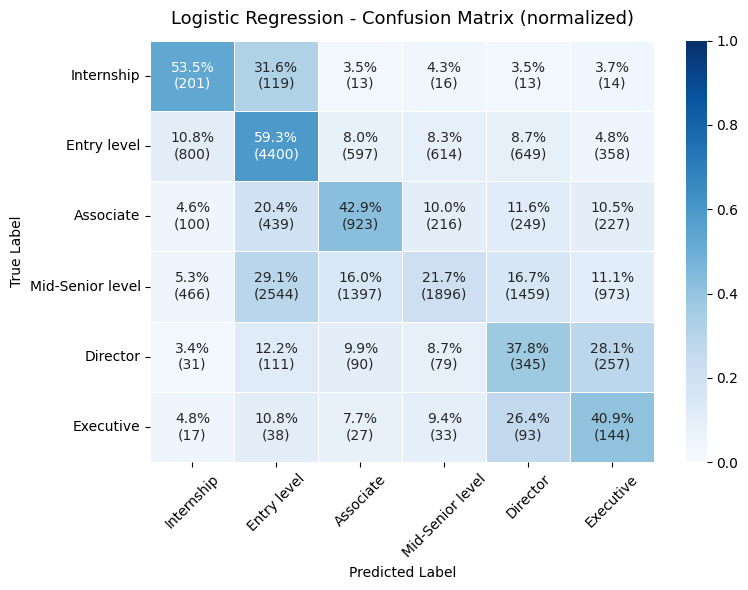

In [125]:
results["Logistic Regression"] = evaluate_model(
    y_test, y_pred_lr, model_name="Logistic Regression"
)

### 4.3 Feature importance

Mean absolute coefficient across all 6 classes. Larger values mean the feature has more influence on the decision boundaries. Since features are scaled, coefficients are directly comparable.

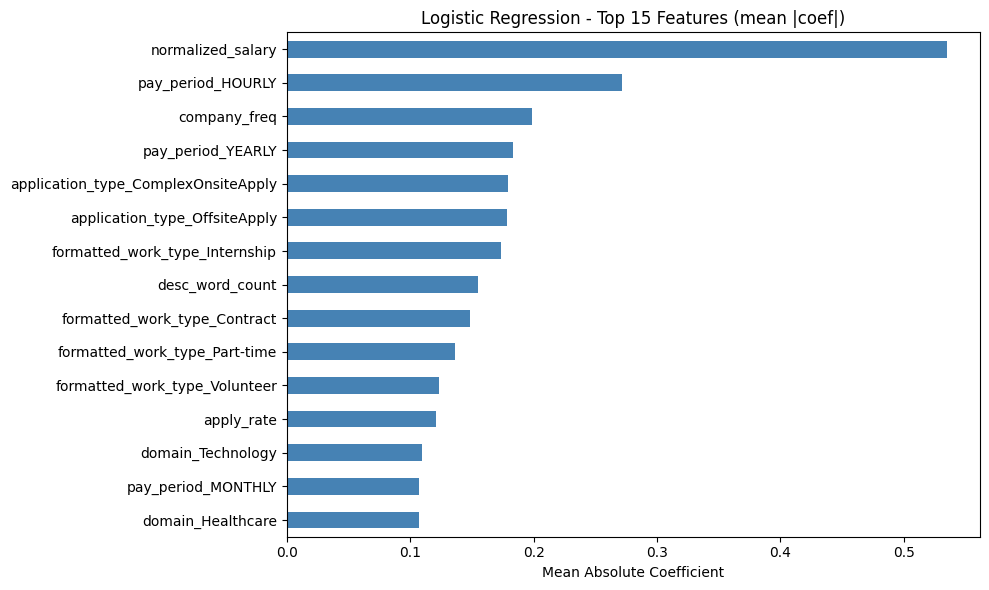

In [126]:
lr_importance = get_feature_importance(lr_pipeline, FEATURES, top_n=15)

fig, ax = plt.subplots(figsize=(10, 6))
lr_importance.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Logistic Regression - Top 15 Features (mean |coef|)")
ax.set_xlabel("Mean Absolute Coefficient")
plt.tight_layout()
plt.show()

## 5. XGBoost

XGBoost is the first tree-based model in the comparison. Unlike Logistic Regression it handles NaN values natively, so no imputation or scaling pipeline is needed.

**Key configuration choices:**
- `sample_weight` computed inversely proportional to class frequency (equivalent to `class_weight='balanced'` in sklearn) to address the heavy class imbalance
- 15% stratified validation split carved from the training set for early stopping on `mlogloss`, which prevents overfitting without manual tuning of `n_estimators`
- `tree_method='hist'` for faster training on larger datasets
- L1/L2 regularization (`reg_alpha`, `reg_lambda`) and `min_child_weight=30` to limit tree complexity

In [127]:
from models.train_xgboost import train_xgboost, get_feature_importance

### 5.1 Train

In [128]:
xgb_model = train_xgboost(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

[0]	validation_0-mlogloss:1.77199
[100]	validation_0-mlogloss:1.31467
[200]	validation_0-mlogloss:1.24073
[300]	validation_0-mlogloss:1.19477
[400]	validation_0-mlogloss:1.16026
[500]	validation_0-mlogloss:1.13435
[600]	validation_0-mlogloss:1.11184
[700]	validation_0-mlogloss:1.09139
[800]	validation_0-mlogloss:1.07373
[900]	validation_0-mlogloss:1.05873
[1000]	validation_0-mlogloss:1.04544
[1100]	validation_0-mlogloss:1.03252
[1200]	validation_0-mlogloss:1.02148
[1300]	validation_0-mlogloss:1.01158
[1400]	validation_0-mlogloss:1.00264
[1500]	validation_0-mlogloss:0.99500
[1600]	validation_0-mlogloss:0.98719
[1700]	validation_0-mlogloss:0.98025
[1800]	validation_0-mlogloss:0.97482
[1900]	validation_0-mlogloss:0.96906
[1999]	validation_0-mlogloss:0.96372


### 5.2 Evaluate

  XGBoost

Accuracy:        0.6014
MAE:             0.6614
F1 (macro):      0.5014
F1 (weighted):   0.6084

                  precision    recall  f1-score   support

      Internship       0.49      0.60      0.54       376
     Entry level       0.68      0.74      0.71      7418
       Associate       0.45      0.68      0.54      2154
Mid-Senior level       0.73      0.48      0.58      8735
        Director       0.25      0.54      0.34       913
       Executive       0.24      0.38      0.29       352

        accuracy                           0.60     19948
       macro avg       0.47      0.57      0.50     19948
    weighted avg       0.65      0.60      0.61     19948



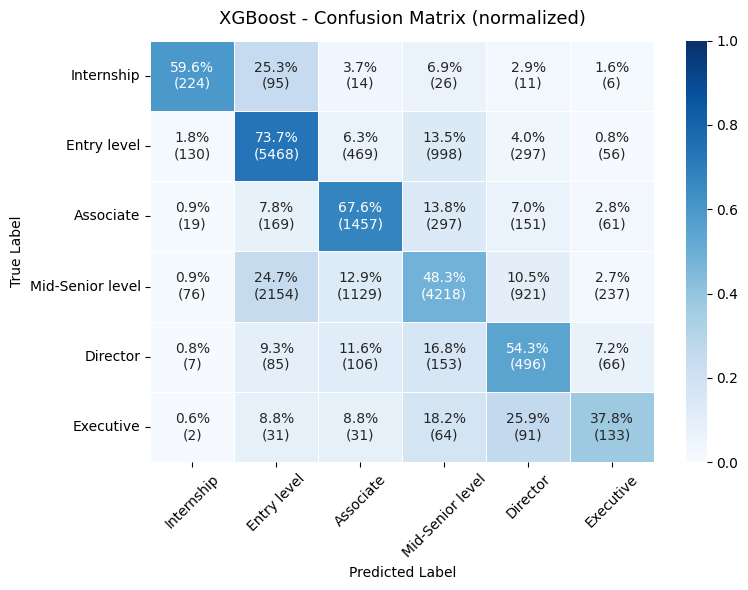

In [129]:
results["XGBoost"] = evaluate_model(
    y_test, y_pred_xgb, model_name="XGBoost"
)

### 5.3 Feature importance

XGBoost reports gain-based importance by default: how much each feature contributes to reducing the loss across all splits where it is used. Higher values indicate stronger predictive signal.


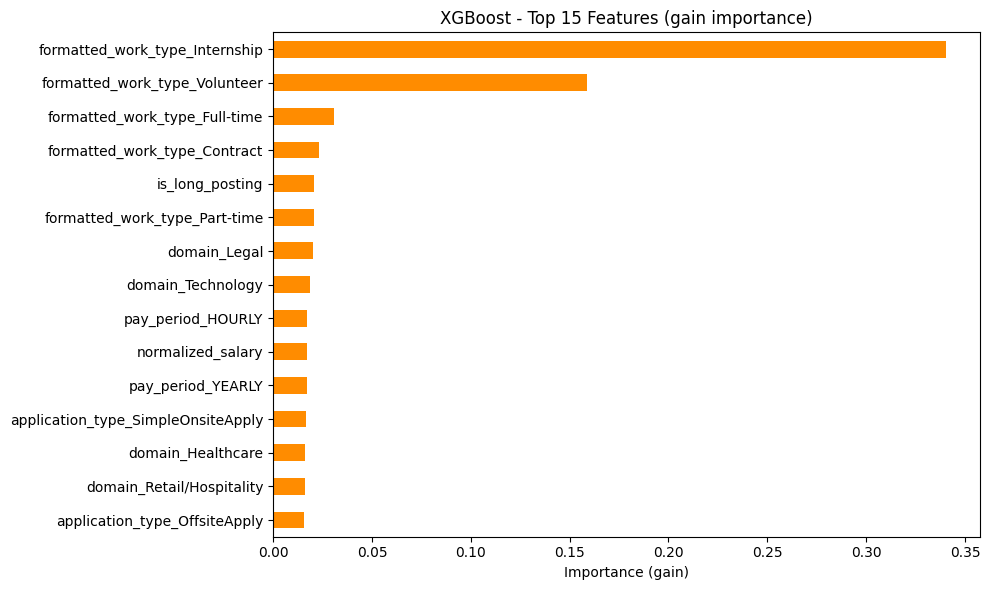

In [130]:
xgb_importance = get_feature_importance(xgb_model, FEATURES, top_n=15)

fig, ax = plt.subplots(figsize=(10, 6))
xgb_importance.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("XGBoost - Top 15 Features (gain importance)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()



## 6. LightGBM
 
LightGBM is the second tree-based model. It uses a leaf-wise growth strategy instead of XGBoost's level-wise approach, which tends to converge faster and often produces lower loss with fewer iterations.
 
**Key differences from XGBoost:**
- Supports `class_weight='balanced'` natively, so no manual sample weight computation is needed
- Leaf-wise growth (`max_depth=-1` with `num_leaves=63`) lets the tree focus splits where they reduce loss the most, rather than filling out every level uniformly
- Default feature importance is split-based (how often a feature is used) rather than gain-based, so raw numbers are not directly comparable to XGBoost's importance values
 
The same early stopping setup is used: 15% stratified validation split, monitoring `multi_logloss`, patience of 100 rounds.

In [131]:
from models.train_lightgbm import train_lightgbm, get_feature_importance as get_feature_importance_lgb

### 6.1 Train

In [132]:
lgb_model = train_lightgbm(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.12605
[200]	valid_0's multi_logloss: 1.03608
[300]	valid_0's multi_logloss: 0.975742
[400]	valid_0's multi_logloss: 0.935932
[500]	valid_0's multi_logloss: 0.905863
[600]	valid_0's multi_logloss: 0.88376
[700]	valid_0's multi_logloss: 0.868081
[800]	valid_0's multi_logloss: 0.858282
[900]	valid_0's multi_logloss: 0.850587
[1000]	valid_0's multi_logloss: 0.845758
[1100]	valid_0's multi_logloss: 0.842472
[1200]	valid_0's multi_logloss: 0.840255
[1300]	valid_0's multi_logloss: 0.839317
[1400]	valid_0's multi_logloss: 0.839561
Early stopping, best iteration is:
[1328]	valid_0's multi_logloss: 0.838824


### 6.2 Evaluate

  LightGBM

Accuracy:        0.6631
MAE:             0.5495
F1 (macro):      0.5565
F1 (weighted):   0.6623

                  precision    recall  f1-score   support

      Internship       0.85      0.53      0.65       376
     Entry level       0.70      0.76      0.73      7418
       Associate       0.50      0.63      0.56      2154
Mid-Senior level       0.71      0.64      0.67      8735
        Director       0.38      0.41      0.39       913
       Executive       0.60      0.24      0.34       352

        accuracy                           0.66     19948
       macro avg       0.62      0.53      0.56     19948
    weighted avg       0.67      0.66      0.66     19948



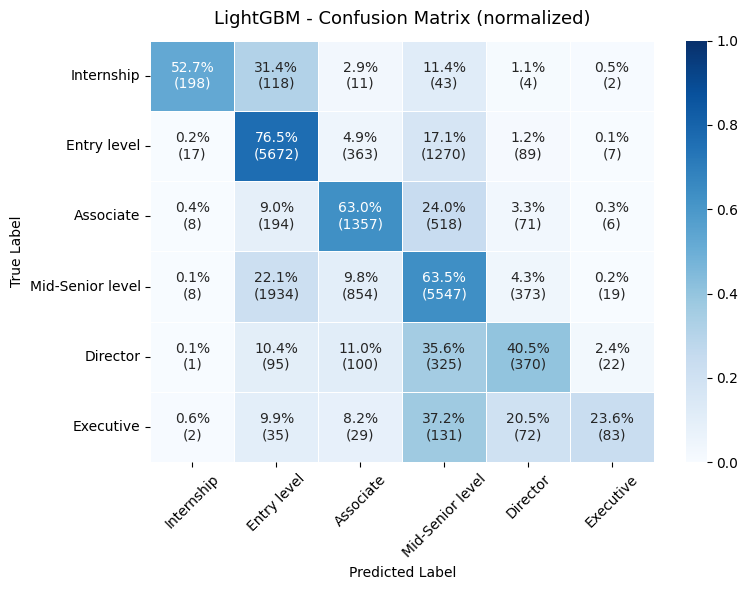

In [133]:
results["LightGBM"] = evaluate_model(
    y_test, y_pred_lgb, model_name="LightGBM"
)

### 6.3 Feature importance

XGBoost reports gain-based importance by default: how much each feature contributes to reducing the loss across all splits where it is used. Higher values indicate stronger predictive signal.


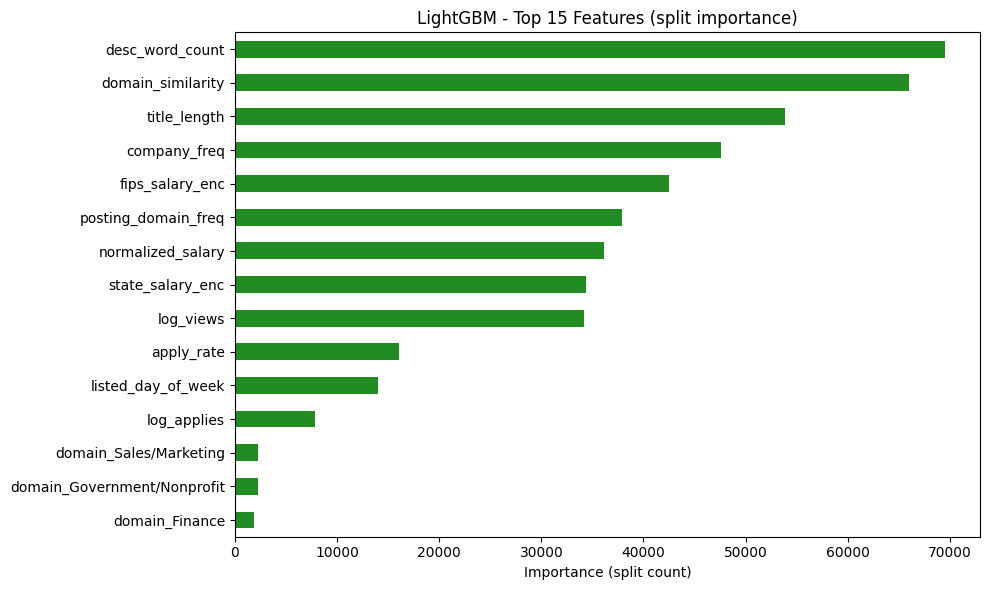

In [134]:
lgb_importance = get_feature_importance_lgb(lgb_model, FEATURES, top_n=15)
 
fig, ax = plt.subplots(figsize=(10, 6))
lgb_importance.sort_values().plot(kind="barh", ax=ax, color="forestgreen")
ax.set_title("LightGBM - Top 15 Features (split importance)")
ax.set_xlabel("Importance (split count)")
plt.tight_layout()
plt.show()

## 7. CatBoost
 
CatBoost is the third and final tree-based model in the comparison. It uses ordered boosting and symmetric trees, which make it particularly resistant to overfitting on small or noisy datasets.
 
**Key differences from XGBoost and LightGBM:**
- Uses `Pool` objects internally for more efficient data handling
- `predict()` returns a 2D array for multiclass problems, so the training module includes a `predict()` helper that flattens and casts to int for consistency
- Boolean columns must be explicitly cast to int (handled automatically inside the training module)
- `bootstrap_type='MVS'` (Minimum Variance Sampling) is used instead of standard row subsampling for more stable gradient estimates
- `depth=8` with symmetric (balanced) trees, meaning every leaf at the same depth uses the same split feature, which acts as a built-in regularizer
- Class weights are computed as a dict and passed via `class_weights` since CatBoost does not accept a `'balanced'` string like LightGBM
 
Iterations raised to 2000 (from the baseline's 500) with early stopping patience of 100 rounds, matching the setup used for XGBoost and LightGBM.

In [141]:
from models.train_catboost import train_catboost, predict as catboost_predict, get_feature_importance as get_feature_importance_cb

### 7.1 Train

In [136]:
cb_model = train_catboost(X_train, y_train)
y_pred_cb = catboost_predict(cb_model, X_test)

0:	learn: 1.7587011	test: 1.7632047	best: 1.7632047 (0)	total: 96.3ms	remaining: 3m 12s
100:	learn: 1.2285255	test: 1.3150467	best: 1.3150467 (100)	total: 9.28s	remaining: 2m 54s
200:	learn: 1.1152460	test: 1.2551993	best: 1.2551993 (200)	total: 19s	remaining: 2m 49s
300:	learn: 1.0240540	test: 1.2139775	best: 1.2139775 (300)	total: 28.2s	remaining: 2m 39s
400:	learn: 0.9564040	test: 1.1932725	best: 1.1932725 (400)	total: 37.5s	remaining: 2m 29s
500:	learn: 0.8991028	test: 1.1810605	best: 1.1810584 (499)	total: 46.3s	remaining: 2m 18s
600:	learn: 0.8497035	test: 1.1733632	best: 1.1733299 (595)	total: 55.3s	remaining: 2m 8s
700:	learn: 0.8035999	test: 1.1682153	best: 1.1682153 (700)	total: 1m 5s	remaining: 2m 1s
800:	learn: 0.7664868	test: 1.1655427	best: 1.1655090 (794)	total: 1m 16s	remaining: 1m 53s
900:	learn: 0.7345214	test: 1.1658303	best: 1.1647153 (836)	total: 1m 26s	remaining: 1m 45s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.164715329
bestIteration = 

### 7.2 Evaluate

  CatBoost

Accuracy:        0.5392
MAE:             0.7732
F1 (macro):      0.4375
F1 (weighted):   0.5462

                  precision    recall  f1-score   support

      Internship       0.30      0.63      0.41       376
     Entry level       0.65      0.71      0.68      7418
       Associate       0.41      0.65      0.50      2154
Mid-Senior level       0.74      0.36      0.49      8735
        Director       0.21      0.55      0.30       913
       Executive       0.17      0.44      0.25       352

        accuracy                           0.54     19948
       macro avg       0.41      0.56      0.44     19948
    weighted avg       0.63      0.54      0.55     19948



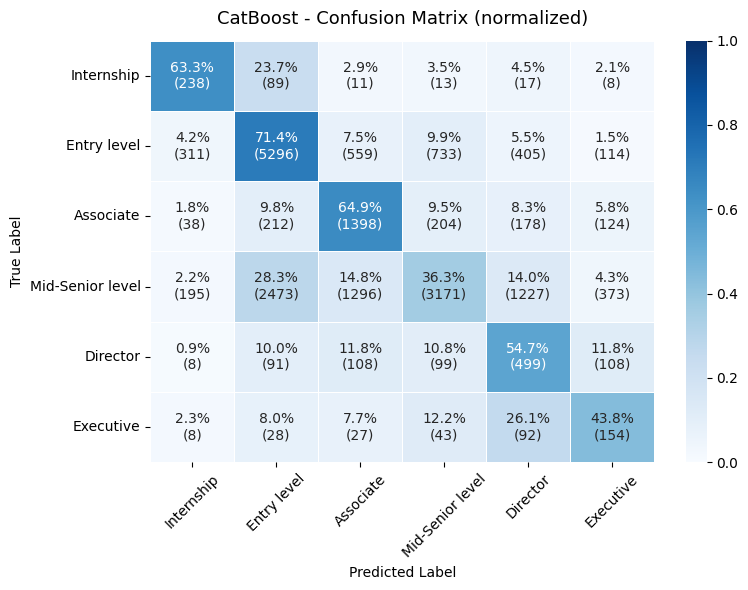

In [137]:
results["CatBoost"] = evaluate_model(
    y_test, y_pred_cb, model_name="CatBoost"
)

### 7.3 Feature importance
 
CatBoost reports PredictionValuesChange importance by default: the average change in the model's prediction when a feature value is changed. This is conceptually closest to XGBoost's gain-based importance and gives a sense of each feature's overall predictive contribution.


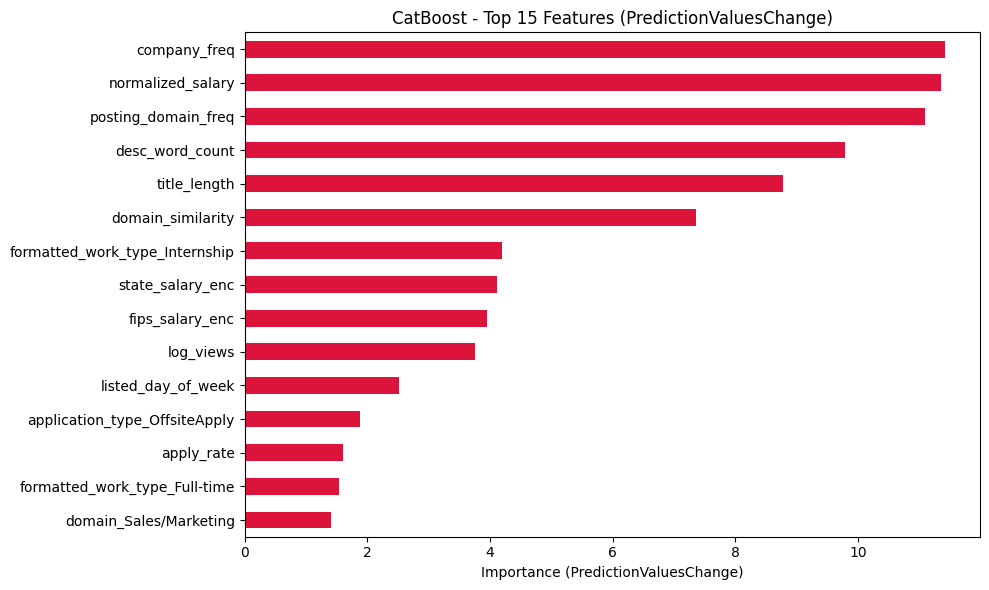

In [140]:
cb_importance = get_feature_importance_cb(cb_model, FEATURES, top_n=15)
 
fig, ax = plt.subplots(figsize=(10, 6))
cb_importance.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_title("CatBoost - Top 15 Features (PredictionValuesChange)")
ax.set_xlabel("Importance (PredictionValuesChange)")
plt.tight_layout()
plt.show()
 

## 8. MLP (Multi-Layer Perceptron)

MLP is the first non-tree-based model in the comparison. It is a fully connected feedforward neural network trained with backpropagation, offering a fundamentally different inductive bias from gradient-boosted trees.

**Key differences from tree-based models:**
- Cannot handle NaN values or unscaled features, so median imputation and standard scaling are applied internally via a sklearn `Pipeline`
- No built-in feature importance; permutation importance is used instead, which measures the drop in accuracy when a single feature is randomly shuffled
- Class imbalance is handled via `sample_weight` using sklearn's `'balanced'` strategy (equivalent to `class_weight='balanced'` in tree-based models)
- Architecture uses three hidden layers `(128, 64, 32)` with `tanh` activation and L2 regularization (`alpha=1e-2`)
- `learning_rate='adaptive'` reduces the learning rate when validation loss stops improving
- sklearn's built-in `early_stopping` carves an internal validation fraction (`validation_fraction=0.13`) from the training data to monitor convergence, separate from our explicit held-out validation set
- `n_iter_no_change=20` provides patience before early stopping triggers

In [143]:
from models.train_mlp import train_mlp, get_feature_importance as get_feature_importance_mlp

### 8.1 Train

In [144]:
mlp_pipeline = train_mlp(X_train, y_train)
y_pred_mlp = mlp_pipeline.predict(X_test)

Iteration 1, loss = 1.41307899
Validation score: 0.428600
Iteration 2, loss = 1.34677132
Validation score: 0.440964
Iteration 3, loss = 1.31597645
Validation score: 0.451843
Iteration 4, loss = 1.28940911
Validation score: 0.465504
Iteration 5, loss = 1.27062567
Validation score: 0.462306
Iteration 6, loss = 1.25151103
Validation score: 0.450606
Iteration 7, loss = 1.22807107
Validation score: 0.446202
Iteration 8, loss = 1.21416649
Validation score: 0.452346
Iteration 9, loss = 1.19492966
Validation score: 0.450278
Iteration 10, loss = 1.17078209
Validation score: 0.455627
Iteration 11, loss = 1.15700941
Validation score: 0.455621
Iteration 12, loss = 1.14015888
Validation score: 0.462630
Iteration 13, loss = 1.12031094
Validation score: 0.466771
Iteration 14, loss = 1.09568405
Validation score: 0.460647
Iteration 15, loss = 1.08157201
Validation score: 0.461016
Iteration 16, loss = 1.06125360
Validation score: 0.462174
Iteration 17, loss = 1.04220890
Validation score: 0.469415
Iterat

### 8.2 Evaluate

  MLP

Accuracy:        0.4472
MAE:             0.9693
F1 (macro):      0.3378
F1 (weighted):   0.4698

                  precision    recall  f1-score   support

      Internship       0.14      0.59      0.23       376
     Entry level       0.61      0.59      0.60      7418
       Associate       0.34      0.51      0.41      2154
Mid-Senior level       0.67      0.31      0.42      8735
        Director       0.16      0.36      0.22       913
       Executive       0.08      0.44      0.14       352

        accuracy                           0.45     19948
       macro avg       0.33      0.47      0.34     19948
    weighted avg       0.57      0.45      0.47     19948



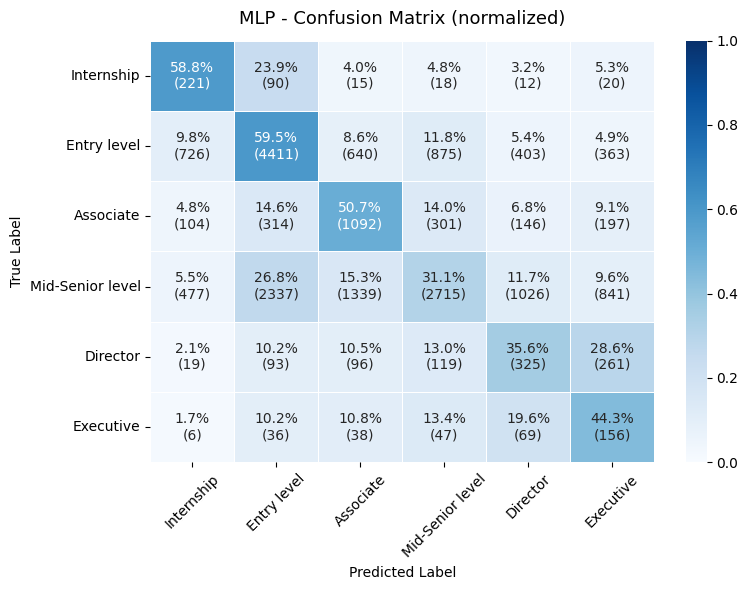

In [147]:
results["MLP"] = evaluate_model(
    y_test, y_pred_mlp, model_name="MLP"
)

### 8.3 Feature importance

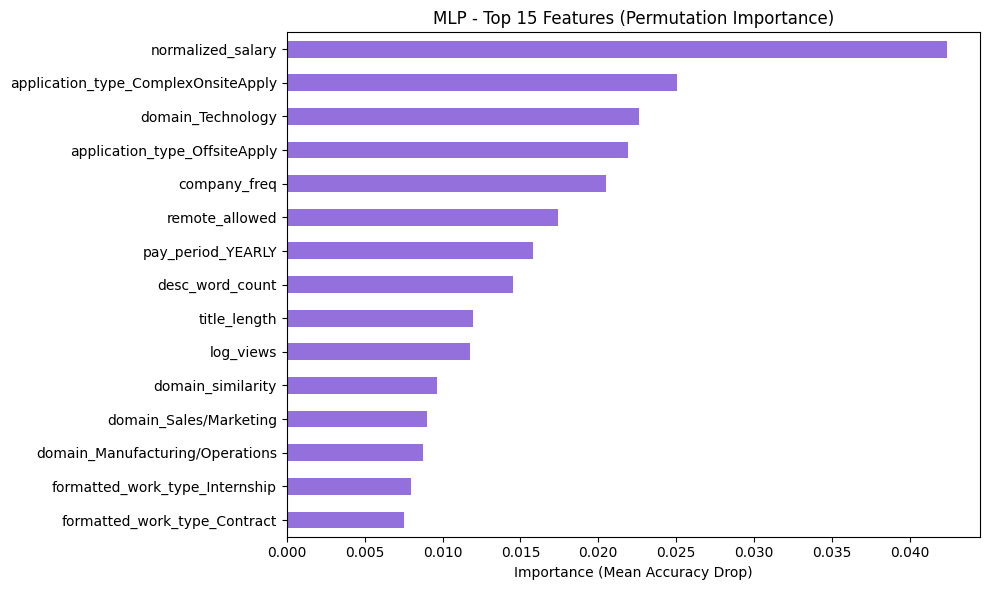

In [148]:
mlp_importance = get_feature_importance_mlp(mlp_pipeline, X_test, y_test, FEATURES, top_n=15)

fig, ax = plt.subplots(figsize=(10, 6))
mlp_importance.sort_values().plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_title("MLP - Top 15 Features (Permutation Importance)")
ax.set_xlabel("Importance (Mean Accuracy Drop)")
plt.tight_layout()
plt.show()

## 9. TabNet

TabNet is an attention-based deep learning architecture designed specifically for tabular data. It uses sequential attention to select which features to focus on at each decision step, giving it built-in feature selection without requiring external methods.

In [149]:
from models.train_tabnet import train_tabnet, predict_tabnet, get_feature_importance as get_feature_importance_tn

### 9.1 Train

In [150]:
tabnet_bundle = train_tabnet(X_train, y_train)
y_pred_tn = predict_tabnet(tabnet_bundle, X_test)

epoch 0  | loss: 1.60581 | val_logloss: 1.54271 |  0:00:02s
epoch 10 | loss: 1.17762 | val_logloss: 1.39343 |  0:00:29s
epoch 20 | loss: 1.01658 | val_logloss: 1.31948 |  0:00:55s
epoch 30 | loss: 0.89982 | val_logloss: 1.35633 |  0:01:28s
epoch 40 | loss: 0.85203 | val_logloss: 1.3677  |  0:01:56s
epoch 50 | loss: 0.81048 | val_logloss: 1.35266 |  0:02:23s
epoch 60 | loss: 0.79362 | val_logloss: 1.37343 |  0:02:50s

Early stopping occurred at epoch 66 with best_epoch = 36 and best_val_logloss = 1.31858


### 9.2 Evaluate

  TabNet

Accuracy:        0.4501
MAE:             0.9544
F1 (macro):      0.3403
F1 (weighted):   0.4637

                  precision    recall  f1-score   support

      Internship       0.15      0.56      0.24       376
     Entry level       0.60      0.63      0.61      7418
       Associate       0.34      0.51      0.41      2154
Mid-Senior level       0.68      0.28      0.40      8735
        Director       0.16      0.47      0.24       913
       Executive       0.10      0.33      0.15       352

        accuracy                           0.45     19948
       macro avg       0.34      0.46      0.34     19948
    weighted avg       0.57      0.45      0.46     19948



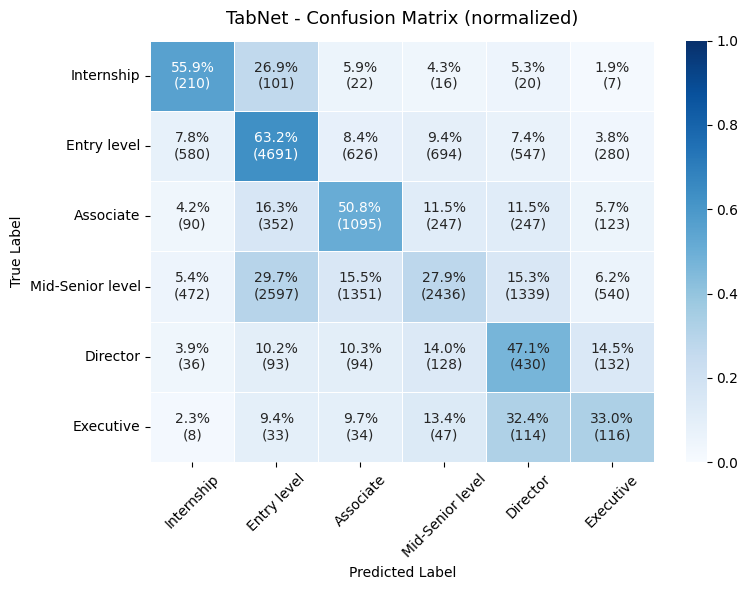

In [151]:
results["TabNet"] = evaluate_model(
    y_test, y_pred_tn, model_name="TabNet"
)

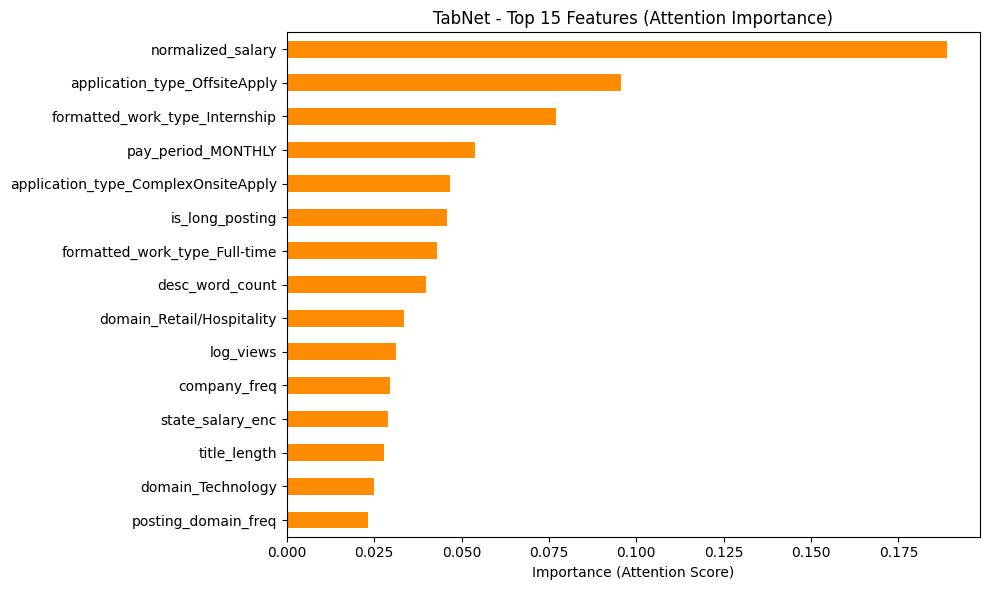

In [152]:
tn_importance = get_feature_importance_tn(tabnet_bundle, FEATURES, top_n=15)

fig, ax = plt.subplots(figsize=(10, 6))
tn_importance.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("TabNet - Top 15 Features (Attention Importance)")
ax.set_xlabel("Importance (Attention Score)")
plt.tight_layout()
plt.show()

## 10. Model Comparison

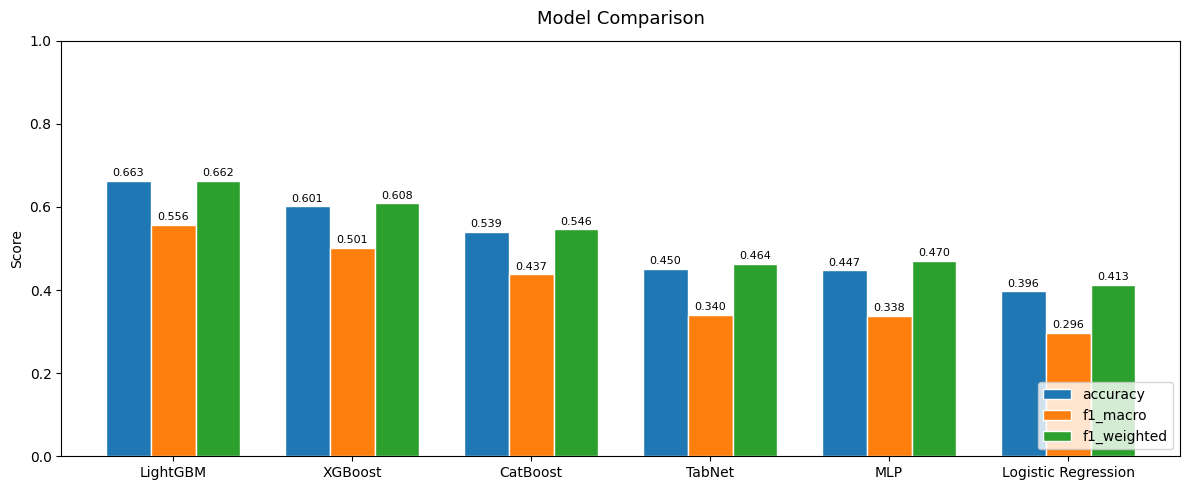

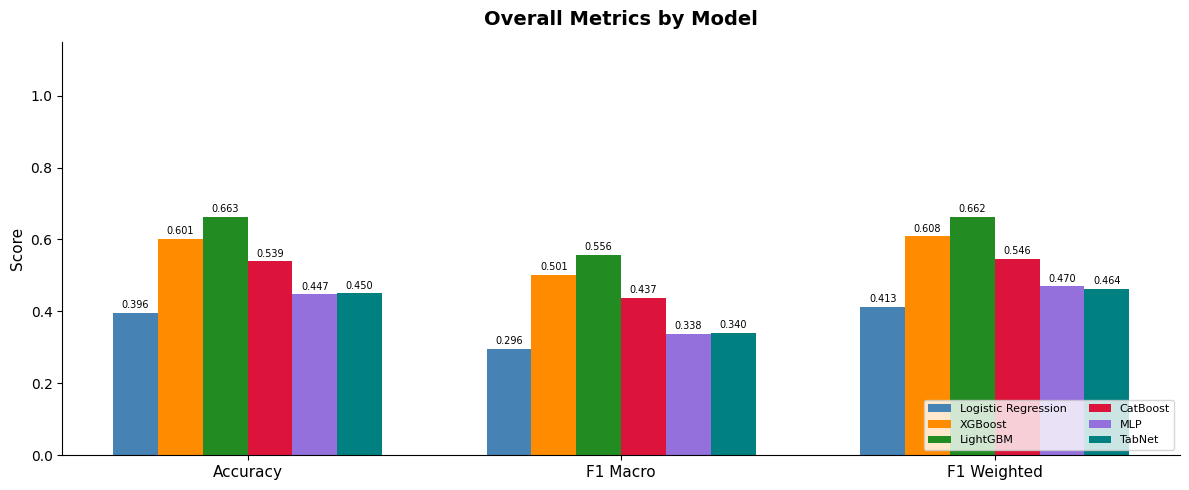

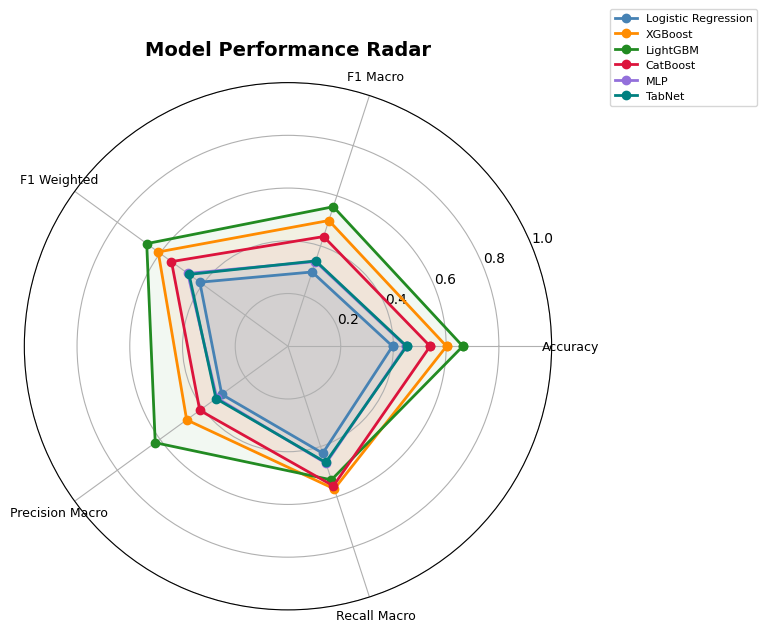

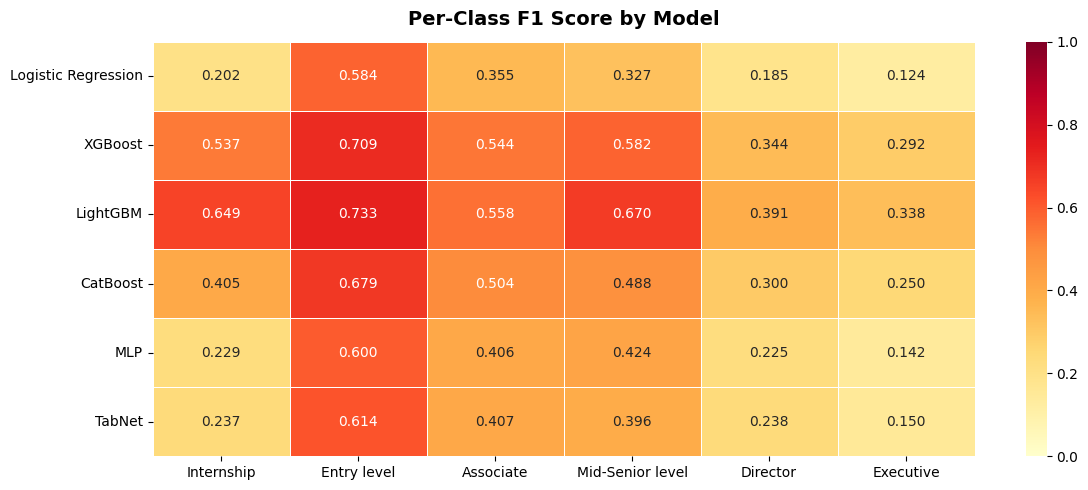

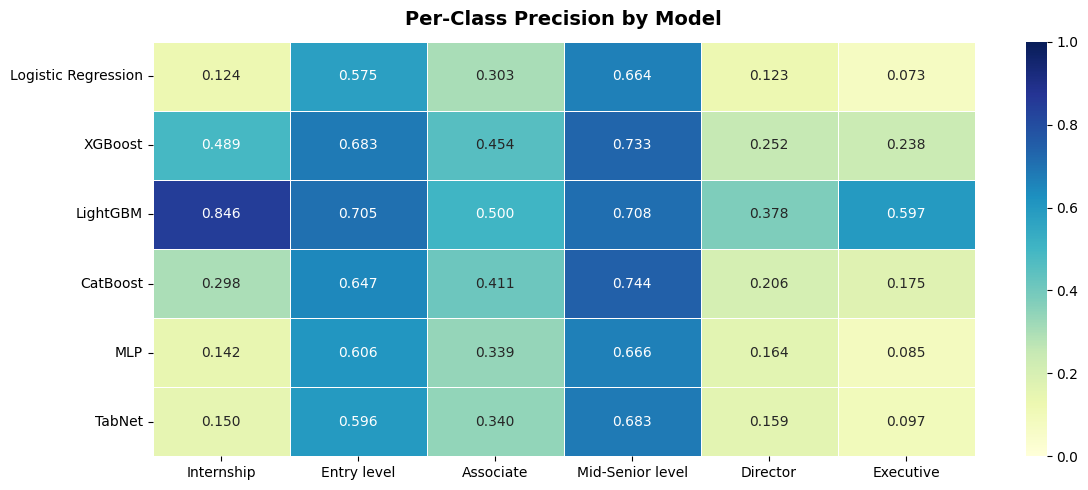

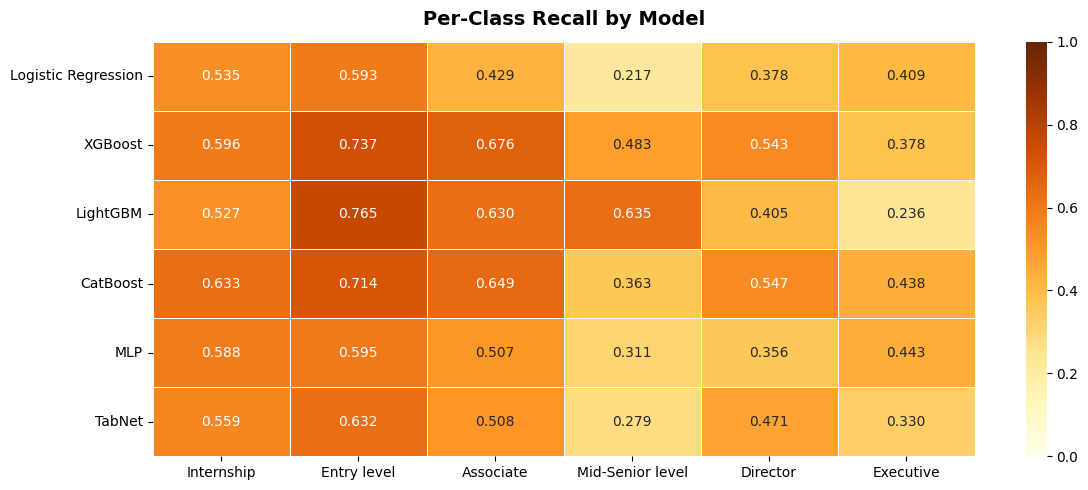

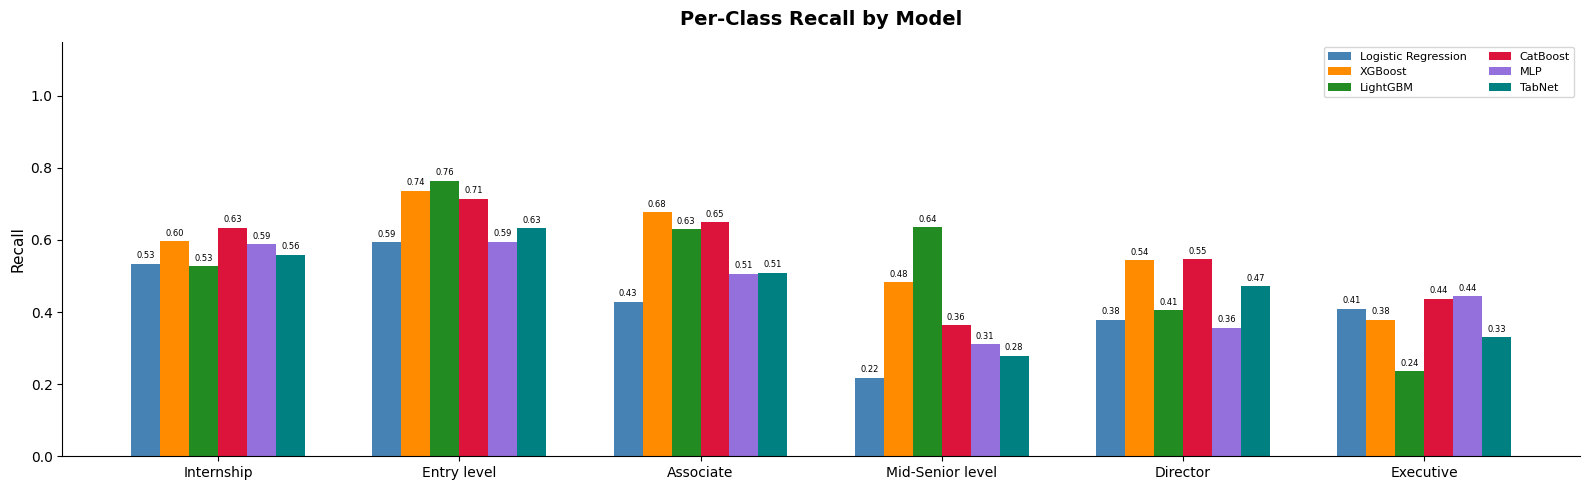

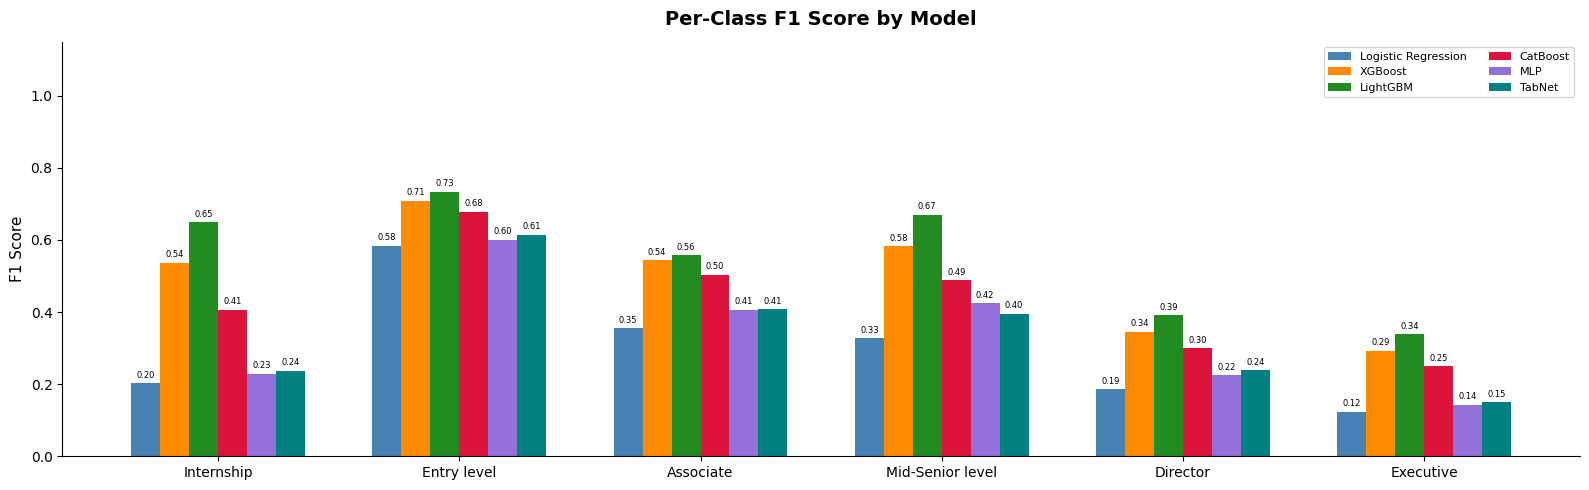

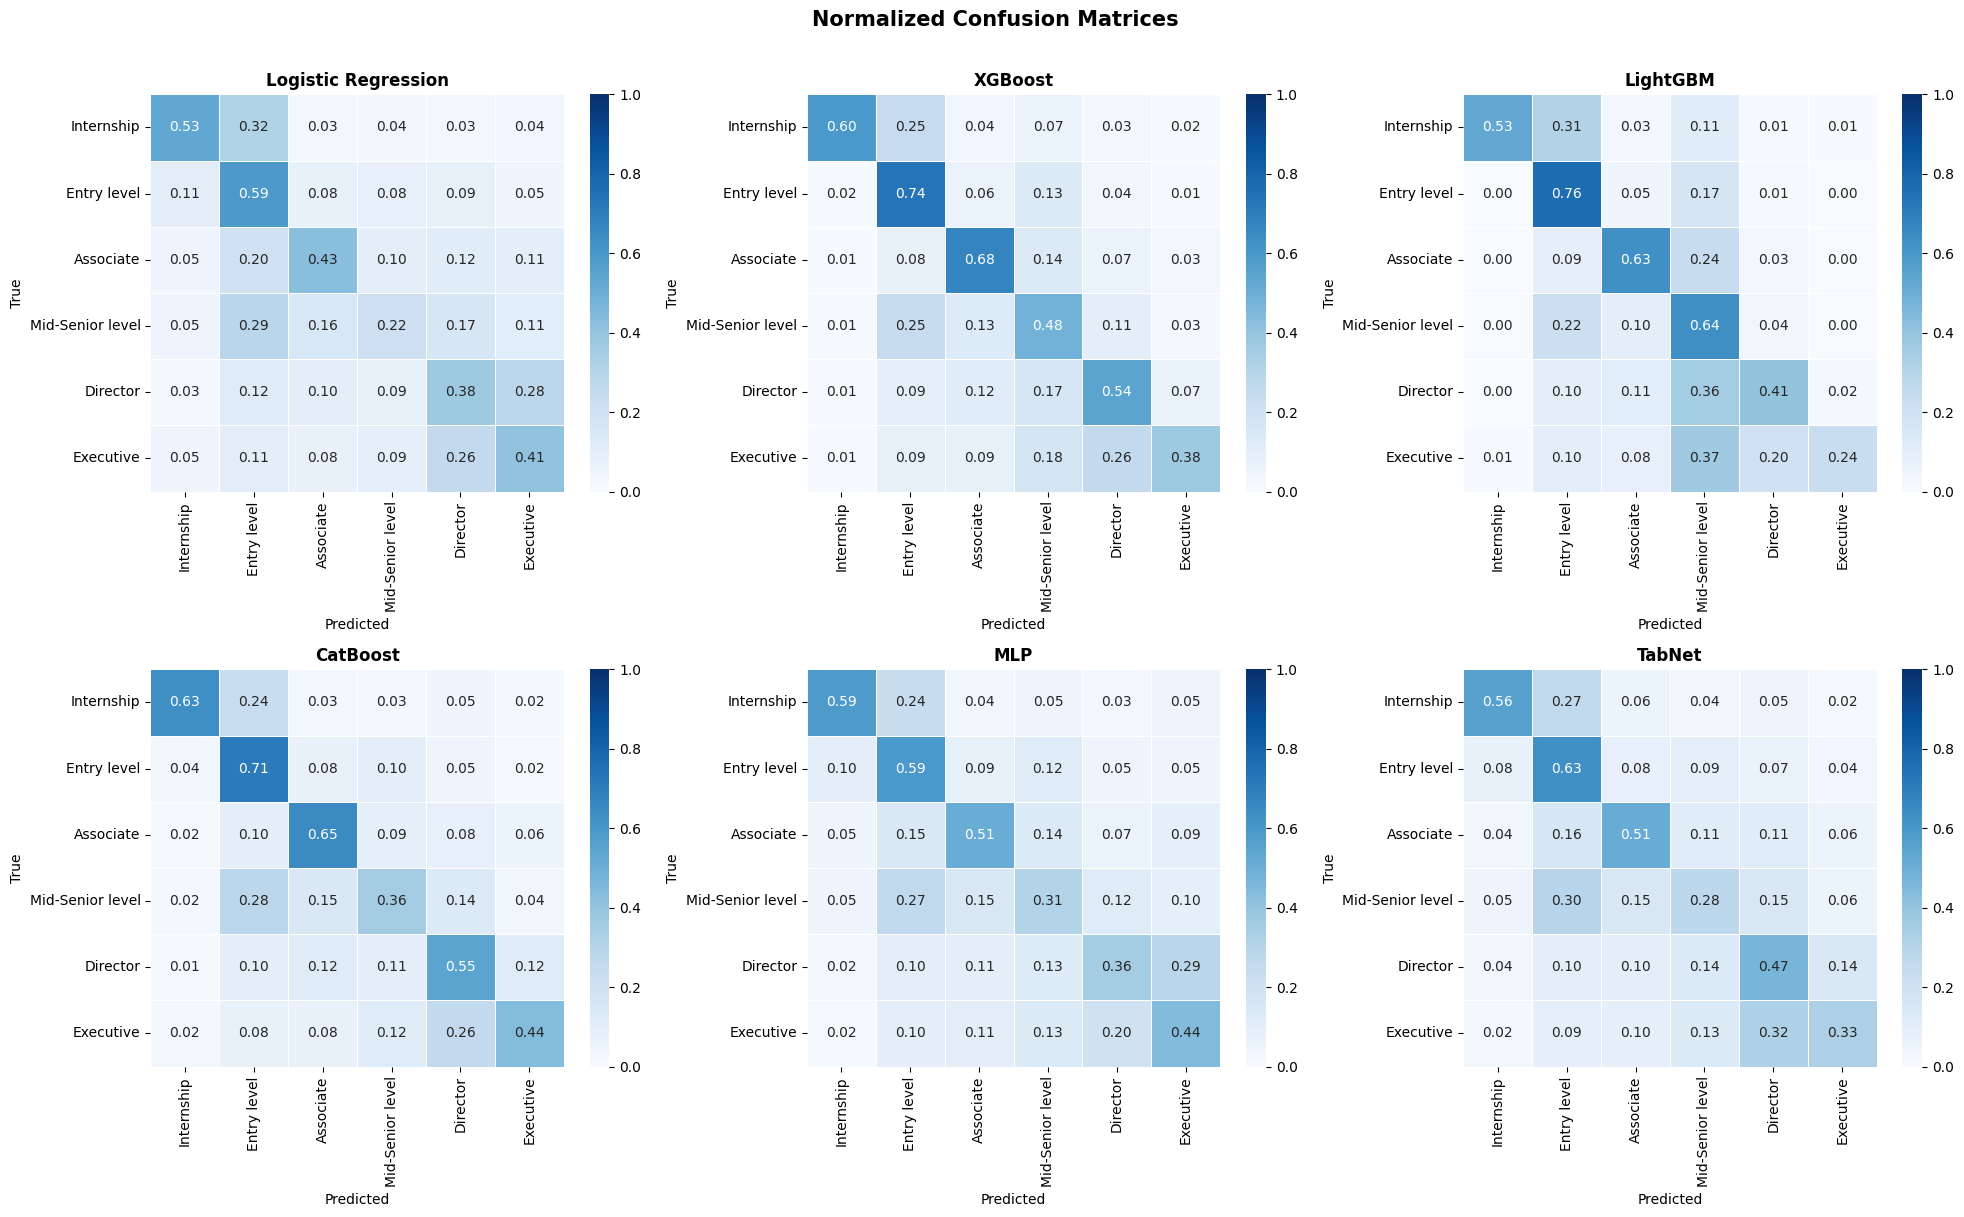

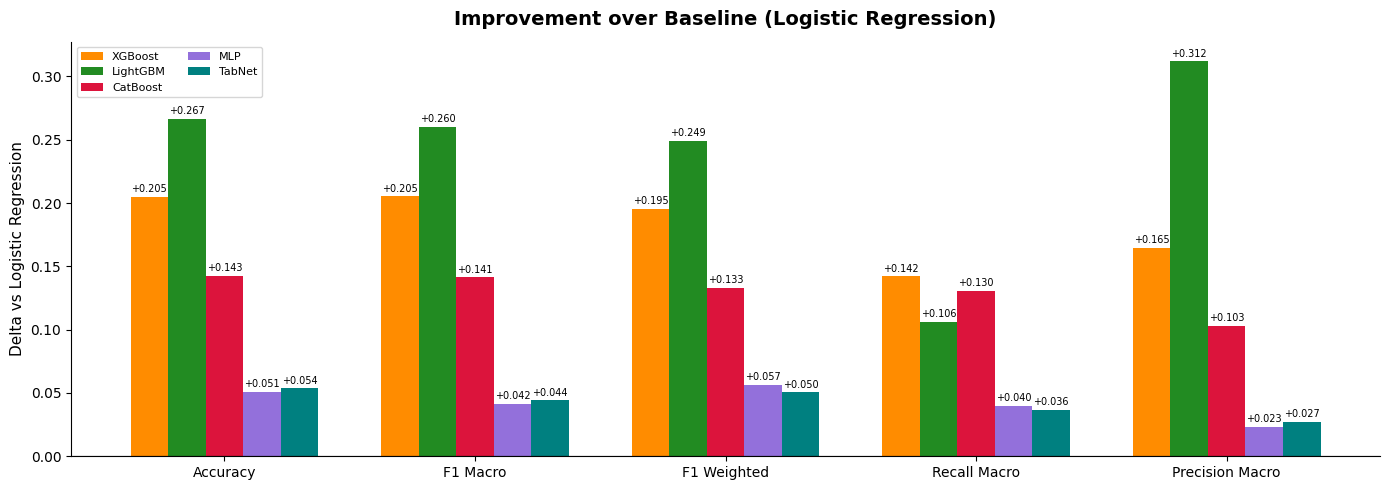

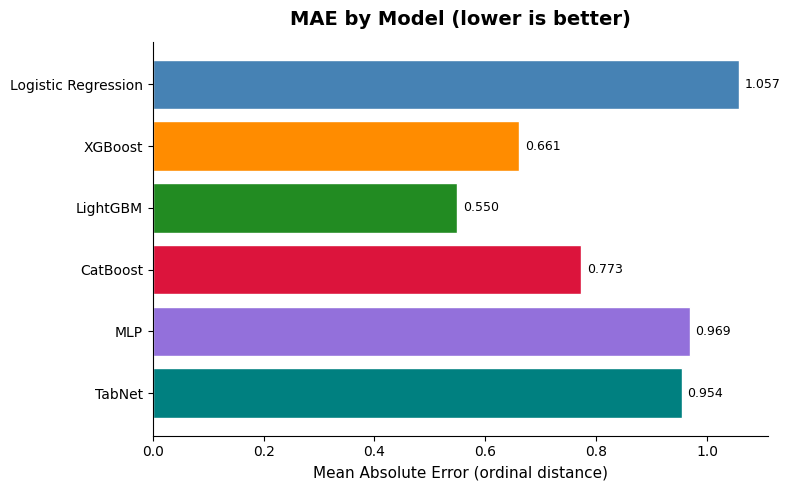

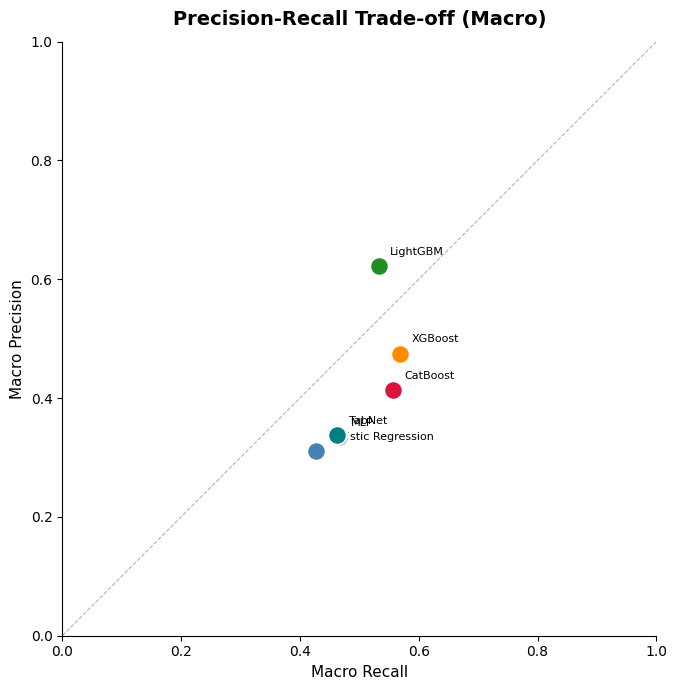

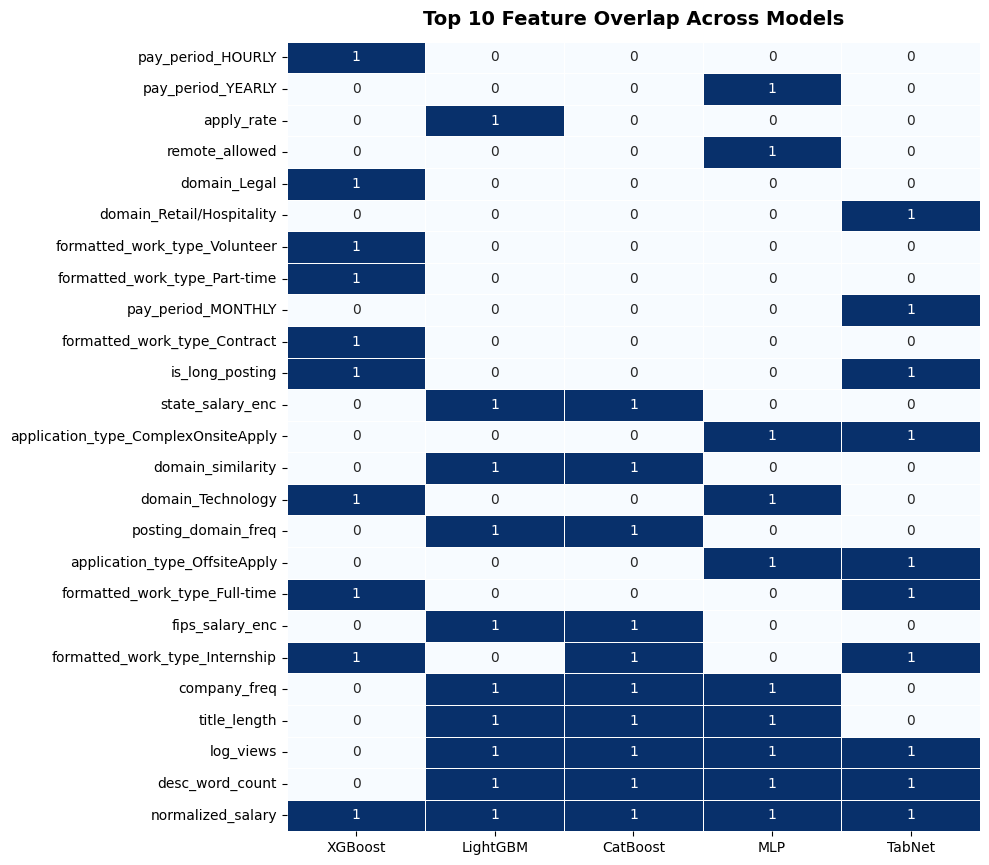

Features in top 10 for ALL five models: ['normalized_salary']


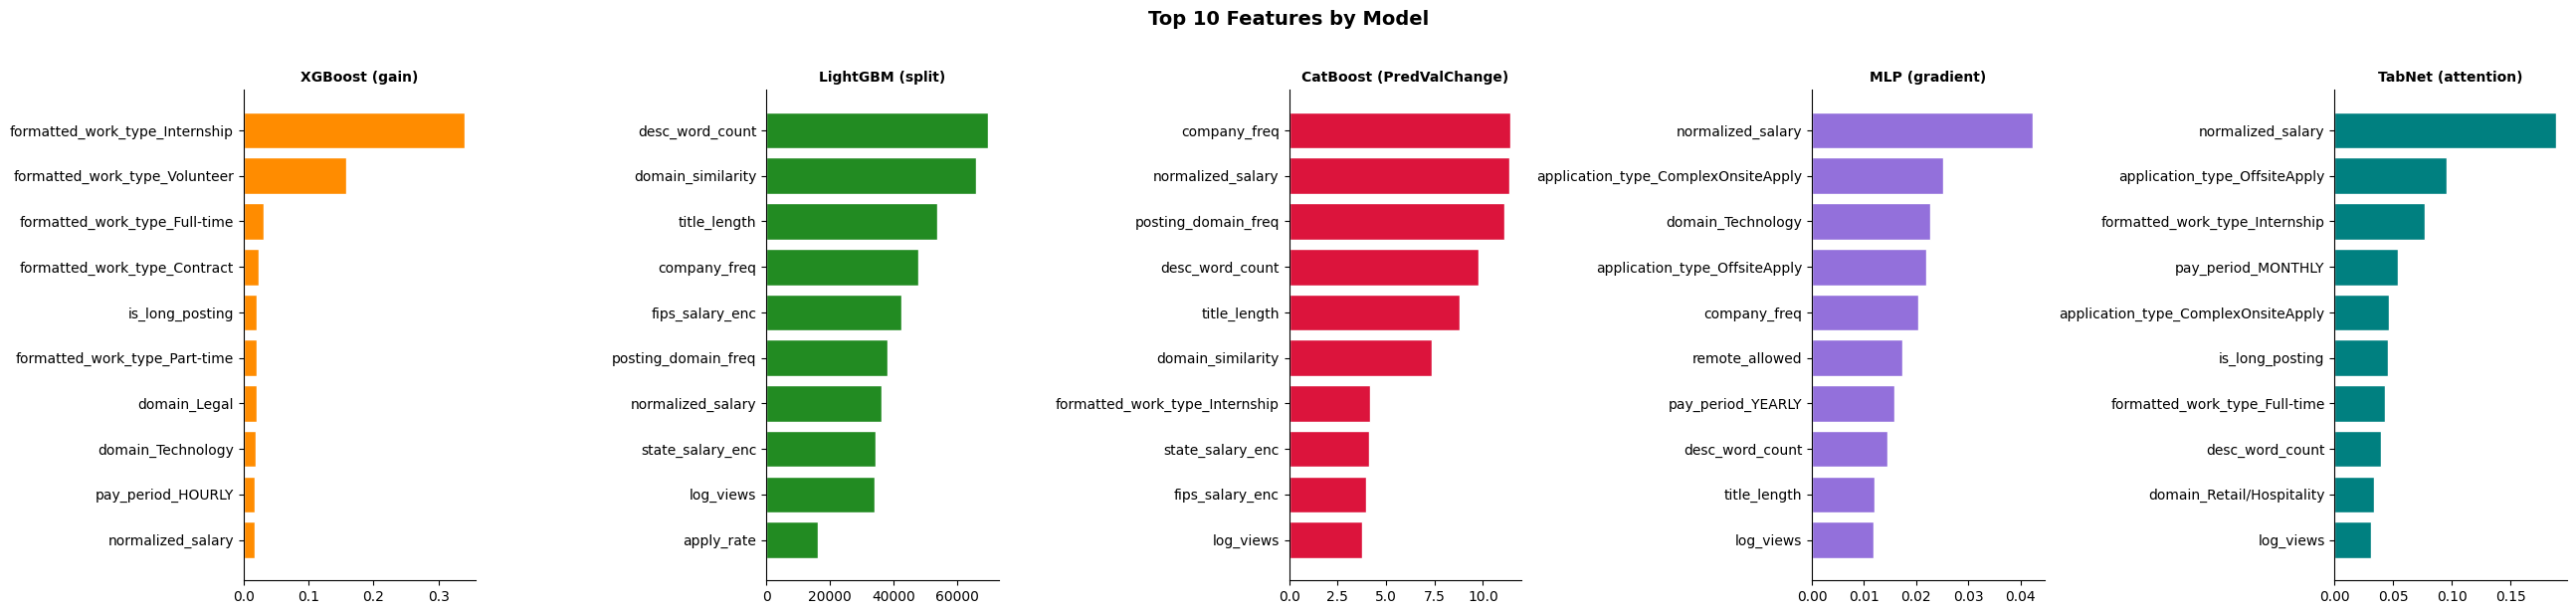

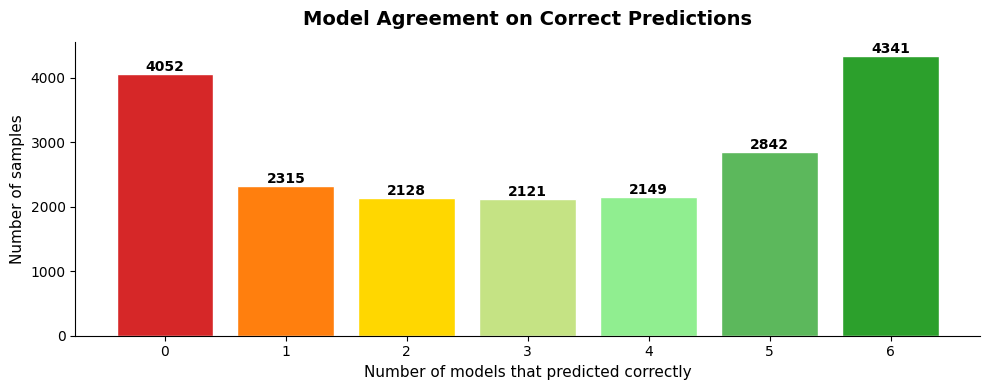

All 6 correct: 4341 (21.8%)
All 6 wrong:   4052 (20.3%)


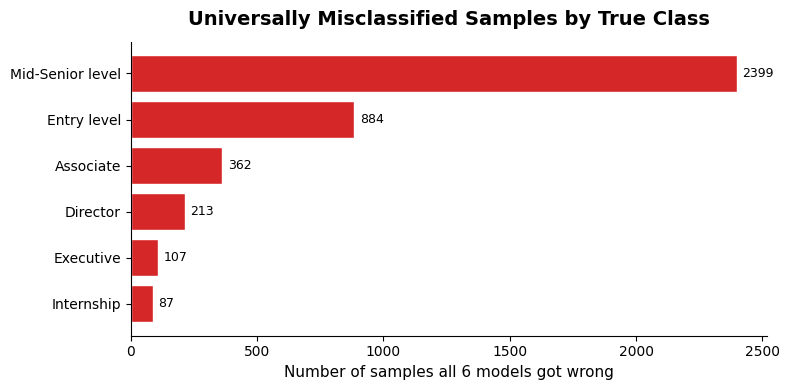

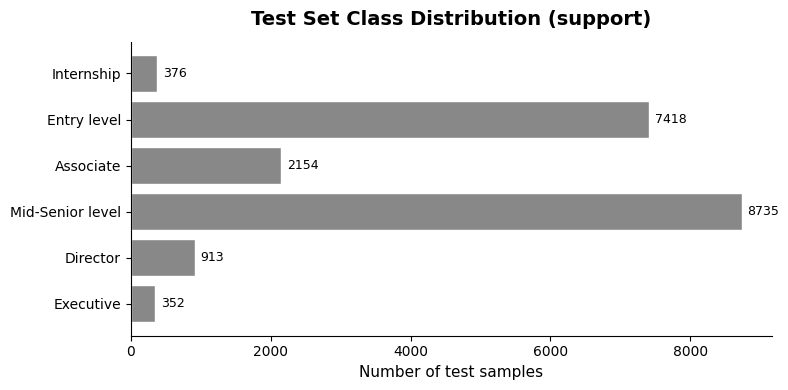

Best model by F1 macro: LightGBM (0.5565)
Baseline (Logistic Regression): 0.2962
Improvement over baseline: +0.2603


In [160]:
# -- Summary table --------------------------------------------
comparison_df = compare_models(results)
comparison_df


# -- Built-in bar comparison ----------------------------------
plot_model_comparison(comparison_df)


# -- Built-in grouped bar chart ----------------------------------
model_names = list(results.keys())
metrics_to_plot = ["accuracy", "f1_macro", "f1_weighted"]
metric_labels = ["Accuracy", "F1 Macro", "F1 Weighted"]
colors = ["steelblue", "darkorange", "forestgreen", "crimson", "mediumpurple", "teal"]

x = np.arange(len(metrics_to_plot))
width = 0.12

fig, ax = plt.subplots(figsize=(12, 5))
for i, model in enumerate(model_names):
    vals = [results[model].get(m, 0) for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors[i % len(colors)])
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Overall Metrics by Model", fontsize=14, fontweight="bold", pad=12)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# -- Radar / spider chart of all aggregate metrics ------------
from math import pi

radar_metrics = ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro"]
radar_labels = ["Accuracy", "F1 Macro", "F1 Weighted", "Precision Macro", "Recall Macro"]
colors_radar = ["steelblue", "darkorange", "forestgreen", "crimson", "mediumpurple", "teal"]

angles = [n / float(len(radar_metrics)) * 2 * pi for n in range(len(radar_metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, model in enumerate(model_names):
    vals = [results[model].get(m, 0) for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=model, color=colors_radar[i % len(colors_radar)])
    ax.fill(angles, vals, alpha=0.06, color=colors_radar[i % len(colors_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Model Performance Radar", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
plt.tight_layout()
plt.show()


# -- Per-class F1 heatmap -------------------------------------
class_names = [EXPERIENCE_LABELS[i] for i in sorted(EXPERIENCE_LABELS.keys())]

per_class_f1 = pd.DataFrame(index=model_names, columns=class_names, dtype=float)
for model_name, metrics in results.items():
    report = metrics["classification_report"]
    for cls_idx, cls_label in EXPERIENCE_LABELS.items():
        cls_key = str(cls_idx) if str(cls_idx) in report else cls_label
        if cls_key in report and isinstance(report[cls_key], dict):
            per_class_f1.loc[model_name, cls_label] = report[cls_key].get("f1-score", 0.0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    per_class_f1.astype(float), annot=True, fmt=".3f",
    cmap="YlOrRd", linewidths=0.5, vmin=0, vmax=1, ax=ax,
)
ax.set_title("Per-Class F1 Score by Model", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


# -- Per-class precision heatmap ------------------------------
per_class_prec = pd.DataFrame(index=model_names, columns=class_names, dtype=float)
for model_name, metrics in results.items():
    report = metrics["classification_report"]
    for cls_idx, cls_label in EXPERIENCE_LABELS.items():
        cls_key = str(cls_idx) if str(cls_idx) in report else cls_label
        if cls_key in report and isinstance(report[cls_key], dict):
            per_class_prec.loc[model_name, cls_label] = report[cls_key].get("precision", 0.0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    per_class_prec.astype(float), annot=True, fmt=".3f",
    cmap="YlGnBu", linewidths=0.5, vmin=0, vmax=1, ax=ax,
)
ax.set_title("Per-Class Precision by Model", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


# -- Per-class recall heatmap ---------------------------------
per_class_recall = pd.DataFrame(index=model_names, columns=class_names, dtype=float)
for model_name, metrics in results.items():
    report = metrics["classification_report"]
    for cls_idx, cls_label in EXPERIENCE_LABELS.items():
        cls_key = str(cls_idx) if str(cls_idx) in report else cls_label
        if cls_key in report and isinstance(report[cls_key], dict):
            per_class_recall.loc[model_name, cls_label] = report[cls_key].get("recall", 0.0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    per_class_recall.astype(float), annot=True, fmt=".3f",
    cmap="YlOrBr", linewidths=0.5, vmin=0, vmax=1, ax=ax,
)
ax.set_title("Per-Class Recall by Model", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


# -- Per-class recall grouped bar chart -----------------------
x = np.arange(len(class_names))
width = 0.12
colors_bar = ["steelblue", "darkorange", "forestgreen", "crimson", "mediumpurple", "teal"]

fig, ax = plt.subplots(figsize=(16, 5))
for i, model_name in enumerate(model_names):
    vals = per_class_recall.loc[model_name].astype(float).values
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors_bar[i % len(colors_bar)])
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylabel("Recall", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class Recall by Model", fontsize=14, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# -- Per-class F1 grouped bar chart --------------------------
fig, ax = plt.subplots(figsize=(16, 5))
for i, model_name in enumerate(model_names):
    vals = per_class_f1.loc[model_name].astype(float).values
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors_bar[i % len(colors_bar)])
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class F1 Score by Model", fontsize=14, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# -- Confusion matrices side by side (2x3 grid) --------------
from sklearn.metrics import confusion_matrix as cm_func

predictions = {
    "Logistic Regression": y_pred_lr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cb,
    "MLP": y_pred_mlp,
    "TabNet": y_pred_tn,
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    present_classes = sorted(y_test.unique())
    cm = cm_func(y_test, y_pred, labels=present_classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    target_names = [EXPERIENCE_LABELS.get(c, str(c)) for c in present_classes]

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=target_names, yticklabels=target_names,
        vmin=0, vmax=1, ax=ax, linewidths=0.5,
    )
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.suptitle("Normalized Confusion Matrices", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# -- Improvement over baseline (LogReg) bar chart ------------
baseline_key = "Logistic Regression"
improvement_metrics = ["accuracy", "f1_macro", "f1_weighted", "recall_macro", "precision_macro"]
improvement_labels = ["Accuracy", "F1 Macro", "F1 Weighted", "Recall Macro", "Precision Macro"]
other_models = [m for m in model_names if m != baseline_key]

fig, ax = plt.subplots(figsize=(14, 5))
x_imp = np.arange(len(improvement_metrics))
width_imp = 0.15

for i, model in enumerate(other_models):
    deltas = [
        results[model].get(m, 0) - results[baseline_key].get(m, 0)
        for m in improvement_metrics
    ]
    bars = ax.bar(x_imp + i * width_imp, deltas, width_imp, label=model,
                  color=colors_bar[(i + 1) % len(colors_bar)])
    ax.bar_label(bars, fmt="%+.3f", fontsize=7, padding=2)

ax.set_xticks(x_imp + width_imp * (len(other_models) - 1) / 2)
ax.set_xticklabels(improvement_labels, fontsize=10)
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.set_ylabel("Delta vs Logistic Regression", fontsize=11)
ax.set_title("Improvement over Baseline (Logistic Regression)", fontsize=14, fontweight="bold", pad=12)
ax.legend(fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# --  MAE comparison (ordinal distance) -----------------------
mae_data = {model: results[model].get("mae", 0) for model in model_names}
mae_series = pd.Series(mae_data)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(mae_series.index, mae_series.values, color=colors_bar[:len(model_names)], edgecolor="white")
ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=4)
ax.set_xlabel("Mean Absolute Error (ordinal distance)", fontsize=11)
ax.set_title("MAE by Model (lower is better)", fontsize=14, fontweight="bold", pad=12)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# --  Macro precision vs macro recall scatter -----------------
fig, ax = plt.subplots(figsize=(8, 7))
for i, model in enumerate(model_names):
    p = results[model].get("precision_macro", 0)
    r = results[model].get("recall_macro", 0)
    ax.scatter(r, p, s=180, color=colors_bar[i % len(colors_bar)], zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(model, (r, p), textcoords="offset points", xytext=(8, 8), fontsize=8)

ax.set_xlabel("Macro Recall", fontsize=11)
ax.set_ylabel("Macro Precision", fontsize=11)
ax.set_title("Precision-Recall Trade-off (Macro)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


# --  Feature importance overlap heatmap (tree + attention models)
from models.train_xgboost import get_feature_importance as get_fi_xgb
from models.train_lightgbm import get_feature_importance as get_fi_lgb
from models.train_catboost import get_feature_importance as get_fi_cb
from models.train_mlp import get_feature_importance as get_fi_mlp
from models.train_tabnet import get_feature_importance as get_fi_tn

top_n = 10
xgb_top = set(get_fi_xgb(xgb_model, FEATURES, top_n=top_n).index)
lgb_top = set(get_fi_lgb(lgb_model, FEATURES, top_n=top_n).index)
cb_top = set(get_fi_cb(cb_model, FEATURES, top_n=top_n).index)
mlp_top = set(get_fi_mlp(mlp_pipeline, X_test, y_test, FEATURES, top_n=top_n).index)
tn_top = set(get_fi_tn(tabnet_bundle, FEATURES, top_n=top_n).index)

all_top = sorted(xgb_top | lgb_top | cb_top | mlp_top | tn_top)
shared_all = xgb_top & lgb_top & cb_top & mlp_top & tn_top

presence = pd.DataFrame(index=all_top, columns=["XGBoost", "LightGBM", "CatBoost", "MLP", "TabNet"])
for feat in all_top:
    presence.loc[feat, "XGBoost"] = 1 if feat in xgb_top else 0
    presence.loc[feat, "LightGBM"] = 1 if feat in lgb_top else 0
    presence.loc[feat, "CatBoost"] = 1 if feat in cb_top else 0
    presence.loc[feat, "MLP"] = 1 if feat in mlp_top else 0
    presence.loc[feat, "TabNet"] = 1 if feat in tn_top else 0

presence["total"] = presence.sum(axis=1)
presence = presence.sort_values("total", ascending=True).drop(columns="total")

fig, ax = plt.subplots(figsize=(10, max(5, len(all_top) * 0.35)))
sns.heatmap(
    presence.astype(int), annot=True, fmt="d", cmap="Blues",
    cbar=False, linewidths=0.5, ax=ax,
)
ax.set_title(f"Top {top_n} Feature Overlap Across Models", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Features in top {top_n} for ALL five models: {sorted(shared_all) if shared_all else 'none'}")


# -- Feature importance side by side (top 10 each) -----------
xgb_imp = get_fi_xgb(xgb_model, FEATURES, top_n=10)
lgb_imp = get_fi_lgb(lgb_model, FEATURES, top_n=10)
cb_imp = get_fi_cb(cb_model, FEATURES, top_n=10)
mlp_imp = get_fi_mlp(mlp_pipeline, X_test, y_test, FEATURES, top_n=10)
tn_imp = get_fi_tn(tabnet_bundle, FEATURES, top_n=10)

fig, axes = plt.subplots(1, 5, figsize=(26, 6))

for ax, imp, title, color in zip(
    axes,
    [xgb_imp, lgb_imp, cb_imp, mlp_imp, tn_imp],
    ["XGBoost (gain)", "LightGBM (split)", "CatBoost (PredValChange)", "MLP (gradient)", "TabNet (attention)"],
    ["darkorange", "forestgreen", "crimson", "mediumpurple", "teal"],
):
    imp_sorted = imp.sort_values()
    ax.barh(imp_sorted.index, imp_sorted.values, color=color, edgecolor="white")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top 10 Features by Model", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# -- Model agreement: how many models predict correctly ------
pred_df = pd.DataFrame({
    "true": y_test,
    "LogReg": y_pred_lr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cb,
    "MLP": y_pred_mlp,
    "TabNet": y_pred_tn,
})

pred_df["n_correct"] = (
    (pred_df["LogReg"] == pred_df["true"]).astype(int) +
    (pred_df["XGBoost"] == pred_df["true"]).astype(int) +
    (pred_df["LightGBM"] == pred_df["true"]).astype(int) +
    (pred_df["CatBoost"] == pred_df["true"]).astype(int) +
    (pred_df["MLP"] == pred_df["true"]).astype(int) +
    (pred_df["TabNet"] == pred_df["true"]).astype(int)
)

agreement_counts = pred_df["n_correct"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#d62728", "#ff7f0e", "#ffd700", "#c5e384", "#90ee90", "#5cb85c", "#2ca02c"]
bars = ax.bar(
    agreement_counts.index.astype(str),
    agreement_counts.values,
    color=[bar_colors[i] for i in agreement_counts.index],
    edgecolor="white",
)
ax.bar_label(bars, fontsize=10, fontweight="bold")
ax.set_xlabel("Number of models that predicted correctly", fontsize=11)
ax.set_ylabel("Number of samples", fontsize=11)
ax.set_title("Model Agreement on Correct Predictions", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

n_models = 6
total = len(pred_df)
all_wrong = (pred_df["n_correct"] == 0).sum()
all_right = (pred_df["n_correct"] == n_models).sum()
print(f"All {n_models} correct: {all_right} ({all_right / total:.1%})")
print(f"All {n_models} wrong:   {all_wrong} ({all_wrong / total:.1%})")


# -- "Hard" samples breakdown by true class ------------------
hard_samples = pred_df[pred_df["n_correct"] == 0]
hard_class_dist = hard_samples["true"].map(EXPERIENCE_LABELS).value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(hard_class_dist.index, hard_class_dist.values, color="#d62728", edgecolor="white")
ax.bar_label(bars, fontsize=9, padding=4)
ax.set_xlabel(f"Number of samples all {n_models} models got wrong", fontsize=11)
ax.set_title("Universally Misclassified Samples by True Class", fontsize=14, fontweight="bold", pad=12)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# -- Per-class support (sample count) context ----------------
support = y_test.map(EXPERIENCE_LABELS).value_counts().reindex(class_names)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(support.index, support.values, color="#888888", edgecolor="white")
ax.bar_label(bars, fontsize=9, padding=4)
ax.set_xlabel("Number of test samples", fontsize=11)
ax.set_title("Test Set Class Distribution (support)", fontsize=14, fontweight="bold", pad=12)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


# -- Best model summary print --------------------------------
best_model = max(results, key=lambda m: results[m].get("f1_macro", 0))
best_f1 = results[best_model].get("f1_macro", 0)
baseline_f1 = results.get("Logistic Regression", {}).get("f1_macro", 0)

print(f"Best model by F1 macro: {best_model} ({best_f1:.4f})")
print(f"Baseline (Logistic Regression): {baseline_f1:.4f}")
print(f"Improvement over baseline: +{best_f1 - baseline_f1:.4f}")

## 11. Model Selection

LightGBM consistently outperformed all other models across the evaluated metrics,
as visible in the radar chart above where its polygon fully encloses the others.
It achieved the highest scores in accuracy, F1 macro, F1 weighted, and precision macro.

The only exception is macro recall, where XGBoost and CatBoost hold a slight edge.
However, this marginal difference does not offset LightGBM's stronger overall profile.

Based on these results, LightGBM is selected as the primary model for
hyperparameter tuning and pipeline improvement in the next phases.